In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
import pandas as pd
import itertools
# Reset to the default Matplotlib color cycle
plt.rcParams['axes.prop_cycle'] = plt.rcParamsDefault['axes.prop_cycle']

In [2]:
# params = np.array([
# ])
# f_200 = np.array([   
# ])
# df = pd.DataFrame(data=np.hstack((params, f_200.reshape(-1,1))),
#                   columns=['tg', 'drive_amp', 'detune', 'f_200'])
# df_detune = df.sort_values(by='tg')
# df_detune

# df_full.to_csv('data/npz/cz_pulse_v0.txt', sep=',', index=False, header=True)
# df_sorted.to_csv('data/npz/cz_pulse_detune_-0.05_-0.1.txt', sep=',', index=False, header=True)

df_v0= pd.read_csv('data/npz/cz_pulse_v0.txt')
df_detune= pd.read_csv('data/npz/cz_pulse_detune_-0.05_-0.1.txt')

cz_se= pd.read_csv('../figure/data/data_cz_3ncut_truc1=300_select.txt')
cz= pd.read_csv('data/data_cz_3ncut_truc1=300.txt')

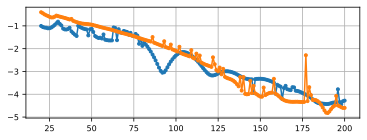

In [3]:
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(df_v0['tg'], df_v0['f_200'], '.-')
plt.plot(df_detune['tg'], df_detune['f_200'], '.-')
plt.grid()

In [4]:
f_ideal_1000 = np.array([
-0.74615650, -0.35735157, -0.40215531, -0.56178381 ,
-0.95811679, -1.15564116, -1.03580528, -1.05336740 ,
-1.20356508, -1.32266091, -1.60649343, -2.21255395 ,
-2.86482092, -2.40556149, -2.16238642, -2.38798190 ,
-2.82838483, -3.00699633, -2.94030583, -3.06534253 ,
-3.24019506, -3.25350188, -3.30892131, -3.52221173 ,
-3.72987194, -3.85810978, -4.09601386, -4.33899580 ,
-4.26563472, -4.12619435, -3.94939514 ,
])
f_ideal_1000_npz = np.array([
-0.72049574, -0.33201747, -0.41058575, -0.60643456 ,
-1.01800388, -1.14577047, -1.00875814, -1.03728788 ,
-1.18763931, -1.31333139, -1.59989737, -2.16729271 ,
-2.65364118, -2.32227948, -2.09225387, -2.28806567 ,
-2.71234580, -3.00976953, -2.91097220, -2.96031838 ,
-3.11780820, -3.16594948, -3.16870582, -3.28996270 ,
-3.41174452, -3.49669505, -3.56362582, -3.66449257 ,
-3.72243185, -3.69454265, -3.68364552 ,
])

f_200_tg_0 = np.array([
-1.00355878, -1.24333334, -1.4473779, -1.32371541 ,
-3.05337003, -2.35115076, -3.0037915, -3.34374839 ,
-3.72748311, -4.27900147, -4.27885363 ,
])

f_200_tg_1 = np.array([
-1.07245002, -1.47715479, -1.17681139, -1.64377048 ,
-2.46342492, -2.85278414, -3.05375236, -3.33402596 ,
-3.83755769, -4.41682576 ,
])
f_200_tg_2 = np.array([
-0.97809998, -1.13451877, -1.64766993, -2.2594689 ,
-2.1480107, -3.17578914, -3.28063401, -3.49173382 ,
-3.97910147, -4.35661976 ,
])

f_200_tg_0_bound = np.array([
-1.06064067, -1.5978517, -2.56850942, -1.83120878 ,
-3.05319374, -2.81797385, -3.00280991, -3.34243314 ,
-3.60805005, -4.28042006, -3.89994672 ,
])
f_200_tg_0_mutation = np.array([
-1.00355119, -0.90135328, -1.55282476, -1.32473193 ,
-3.05336354, -2.35154197, -3.00361287, -3.34536466 ,
-3.72859765, -4.28029589, -3.9009206 ,
])
f_200_tg_0_tol = np.array([
-1.00384989, -0.9841791, -1.55494839, -1.42932378 ,
-3.05417588, -2.35227798, -3.00387987, -3.34546797 ,
-3.72885583, -4.2801667, -4.27881127 ,
])

f_1500_v0 = np.array([
-0.21915923, -0.40967115, -0.33609818, -0.24024013 ,
-1.00736609, -1.14156290, -0.18028668, -0.14727562 ,
-1.31700828, -1.43793830, -0.46441269, -2.23567166 ,
-2.89169765, -2.37804468, -2.09830886, -2.31670542 ,
-2.81558916, -3.14760120, -2.99361205, -3.04875535 ,
-3.27293481, -3.92516830, -3.32738931, -3.48632667 ,
-3.72068796, -3.69283407, -3.97284124, -4.26566973 ,
-4.40093533, -4.34645313, -4.27056340 ,
])


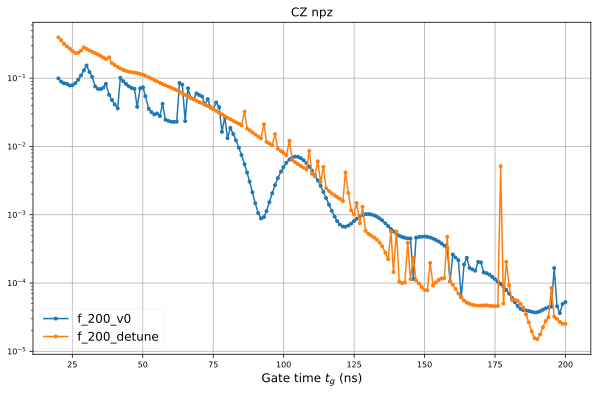

In [5]:

fig, ax = plt.subplots(figsize=(10,6))
# ax.plot(cz_se['tg'], 10**f_ideal_1000, '.-',  label=r'f_1000_old')
# ax.plot(cz_se['tg'], 10**f_ideal_1000_npz, '.--',  label=r'f_1000_npz')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0, 'bs',  label=r'f_200_v1')
# ax.plot(cz_se['tg'][1::3], 10**f_200_tg_1, 'bs')
# ax.plot(cz_se['tg'][2::3], 10**f_200_tg_2, 'bs')
plt.plot(df_v0['tg'], 10**df_v0['f_200'], '.-', label=r'f_200_v0')
plt.plot(df_detune['tg'], 10**df_detune['f_200'], '.-', label=r'f_200_detune')
# plt.plot(df_v0[0::6]['tg'], 10**f_ideal_1500, '.-', label=r'f_1500_v0')

# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_bound, '.-',  label=r'f_200_tg_0_bound')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_mutation, 'x-',  label=r'f_200_tg_0_mutation')
# ax.plot(cz_se['tg'][0::3], 10**f_200_tg_0_tol, '+-',  label=r'f_200_tg_0_tol')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CZ npz', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

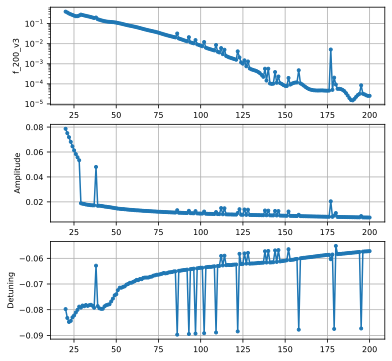

In [6]:
fig, ax = plt.subplots(3,1,figsize=(6,6))

ax[0].plot(df_detune['tg'], 10**df_detune['f_200'], '.-')
ax[0].set_ylabel('f_200_v3')
ax[0].set_yscale('log')

ax[1].plot(df_detune['tg'], df_detune['drive_amp'], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(df_detune['tg'], df_detune['detune'], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()

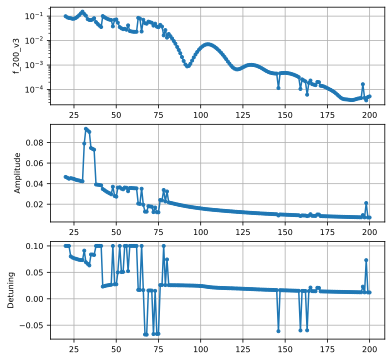

In [7]:
fig, ax = plt.subplots(3,1,figsize=(6,6))

ax[0].plot(df_v0['tg'], 10**df_v0['f_200'], '.-')
ax[0].set_ylabel('f_200_v3')
ax[0].set_yscale('log')

ax[1].plot(df_v0['tg'], df_v0['drive_amp'], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(df_v0['tg'], df_v0['detune'], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()

(0.0, 0.11)

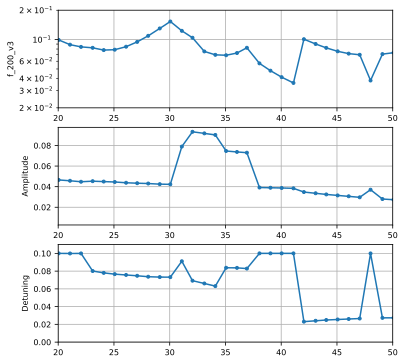

: 

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(6,6))

ax[0].plot(df_v0['tg'], 10**df_v0['f_200'], '.-')
ax[0].set_ylabel('f_200_v3')
ax[0].set_yscale('log')

ax[1].plot(df_v0['tg'], df_v0['drive_amp'], '.-')
ax[1].set_ylabel('Amplitude')

ax[2].plot(df_v0['tg'], df_v0['detune'], '.-')
ax[2].set_ylabel('Detuning')
for a in ax:
    a.grid()
    a.set_xlim(20, 50)
ax[0].set_ylim(2e-2, 2e-1)    
ax[2].set_ylim(0, 0.11)    

### CZ Infidelity convergence on truncation

max_step=1e-4

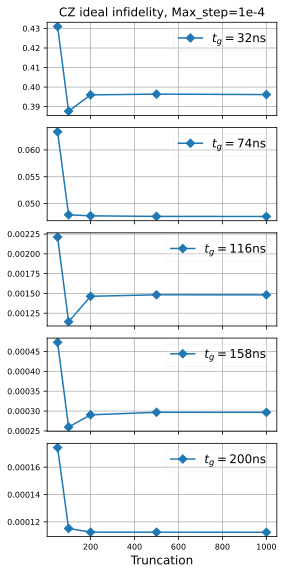

In [4]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('Truncation', fontsize=12)
ax[0].set_title(fr'CZ ideal infidelity, Max_step=1e-4', fontsize=12)
plt.tight_layout()

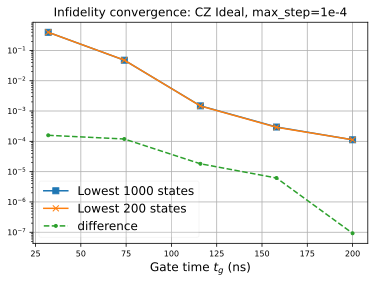

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_200, 'x-',  label=r'Lowest 200 states')
ax.plot(tg_list, np.abs(10**f_ideal_200 - 10**f_ideal_1000), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent